<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week5/breast_cancer_DL_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week2/breast_cancer.csv'
df = pd.read_csv(path)
df

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [5]:
# 결측치 확인
df.isnull().sum()

,0
Unnamed: 0,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0


/tmp/ipykernel_24843/3967543009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="mean radius", data=df, palette="Set3")


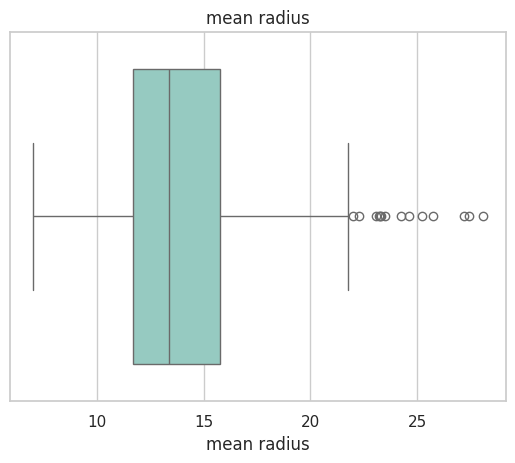

In [7]:
# 이상치 확인
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
sns.boxplot(x="mean radius", data=df, palette="Set3")
plt.title("mean radius")
plt.show()

In [10]:
y = df['label']
print(y.value_counts())

label
1    357
0    212
Name: count, dtype: int64


In [12]:
X = df.drop('label', axis=1)
X.head()

,Unnamed: 0,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 1. 데이터 형태 변환 + One-Hot Encoding + 데이터 분할 + Scaling

- 근데, breast_cancer인 경우, **Binary Classification**이다. 이럴 때는 **One-Hot-Encoding이 필요 없다.**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.values # numpy 배열로 전환
Y = y.values # One-Hot Encoding 이후, numpy 배열로 전환

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0, stratify=y
) # 데이터 분할

scaler = StandardScaler() # 스케일러 객체 생성
X_train = scaler.fit_transform(X_train) # 학습(Train)데이터를 통해 학습(fit) 후에 적용(transform)
X_test = scaler.transform(X_test) # 테스트 데이터는 제외해서 학습(데이터 누수를 막기 위해)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(455, 31) (114, 31)
(455,) (114,)


## 2. 딥러닝 모델 생성, 학습, 평가

In [14]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 shape는 입력 열 개수(현재 31)
    layers.Dense(64, activation='relu'), # 은닉층(64개)
    layers.Dropout(0.3), # Dropout으로 랜덤하게 뉴런의 30% 을 제외시킴(끔). overfitting을 막기 위함.
    layers.Dense(32, activation='relu'), # 은닉층(32개)
    layers.Dense(1, activation='sigmoid') #출력층 (y_train.shape[1]만큼 출력함.(현재 1))
    # binary classification이므로 activation이 sigmoid
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # binary_crossentropy
    metrics=['accuracy'] # Classification이므로 metrics가 accurancy이다.
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.8187 - loss: 0.4963 - val_accuracy: 0.9231 - val_loss: 0.2969
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9478 - loss: 0.2346 - val_accuracy: 0.9341 - val_loss: 0.1698
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9560 - loss: 0.1603 - val_accuracy: 0.9451 - val_loss: 0.1222
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9753 - loss: 0.1062 - val_accuracy: 0.9451 - val_loss: 0.1016
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9780 - loss: 0.0975 - val_accuracy: 0.9451 - val_loss: 0.0884
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9780 - loss: 0.0831 - val_accuracy: 0.9560 - val_loss: 0.0840
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9835 - loss: 0.0676 - val_accuracy: 0.9451 - val_loss: 0.0737
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9890 - loss: 0.0615 - val_accuracy: 0.9560 - va

## 3. 예측 및 평가

In [15]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

y_pred_class = (y_pred >= 0.5).astype(int).ravel()
y_test_class = y_test.ravel()



print(classification_report(y_test_class, y_pred_class))
print(confusion_matrix(y_test_class, y_pred_class))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[39  3]
 [ 2 70]]


## 4. 학습 과정 시각화

In [16]:
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(loss) + 1)

## 손실 그래프

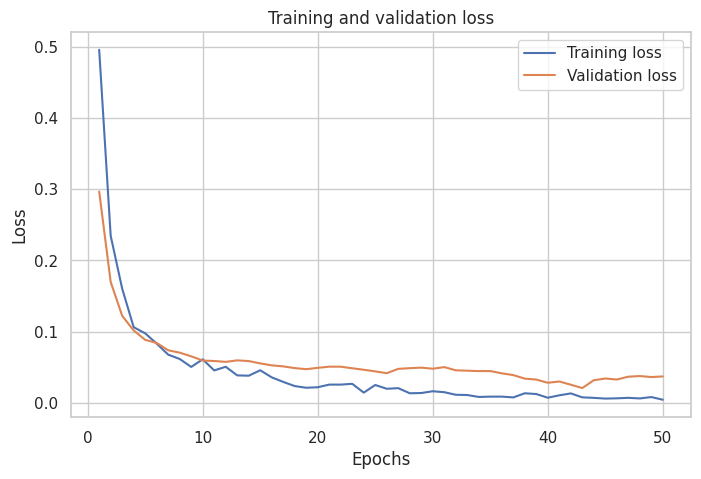

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 정확도 그래프

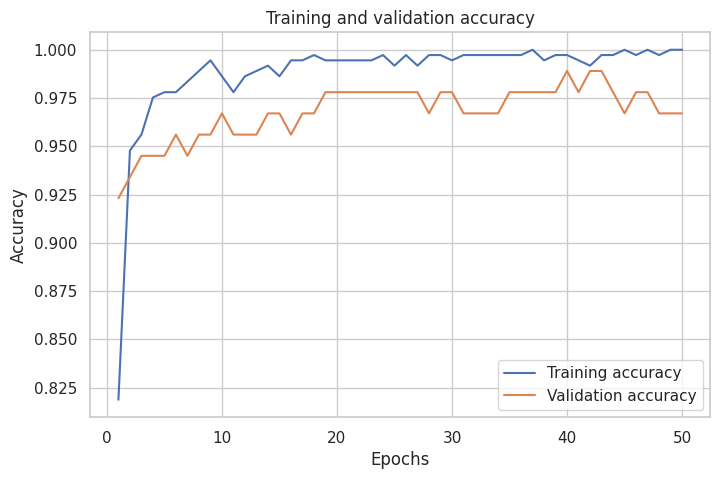

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training accuracy')
plt.plot(epochs, val_acc, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()